Anthony Adungo Machine Learning Project.

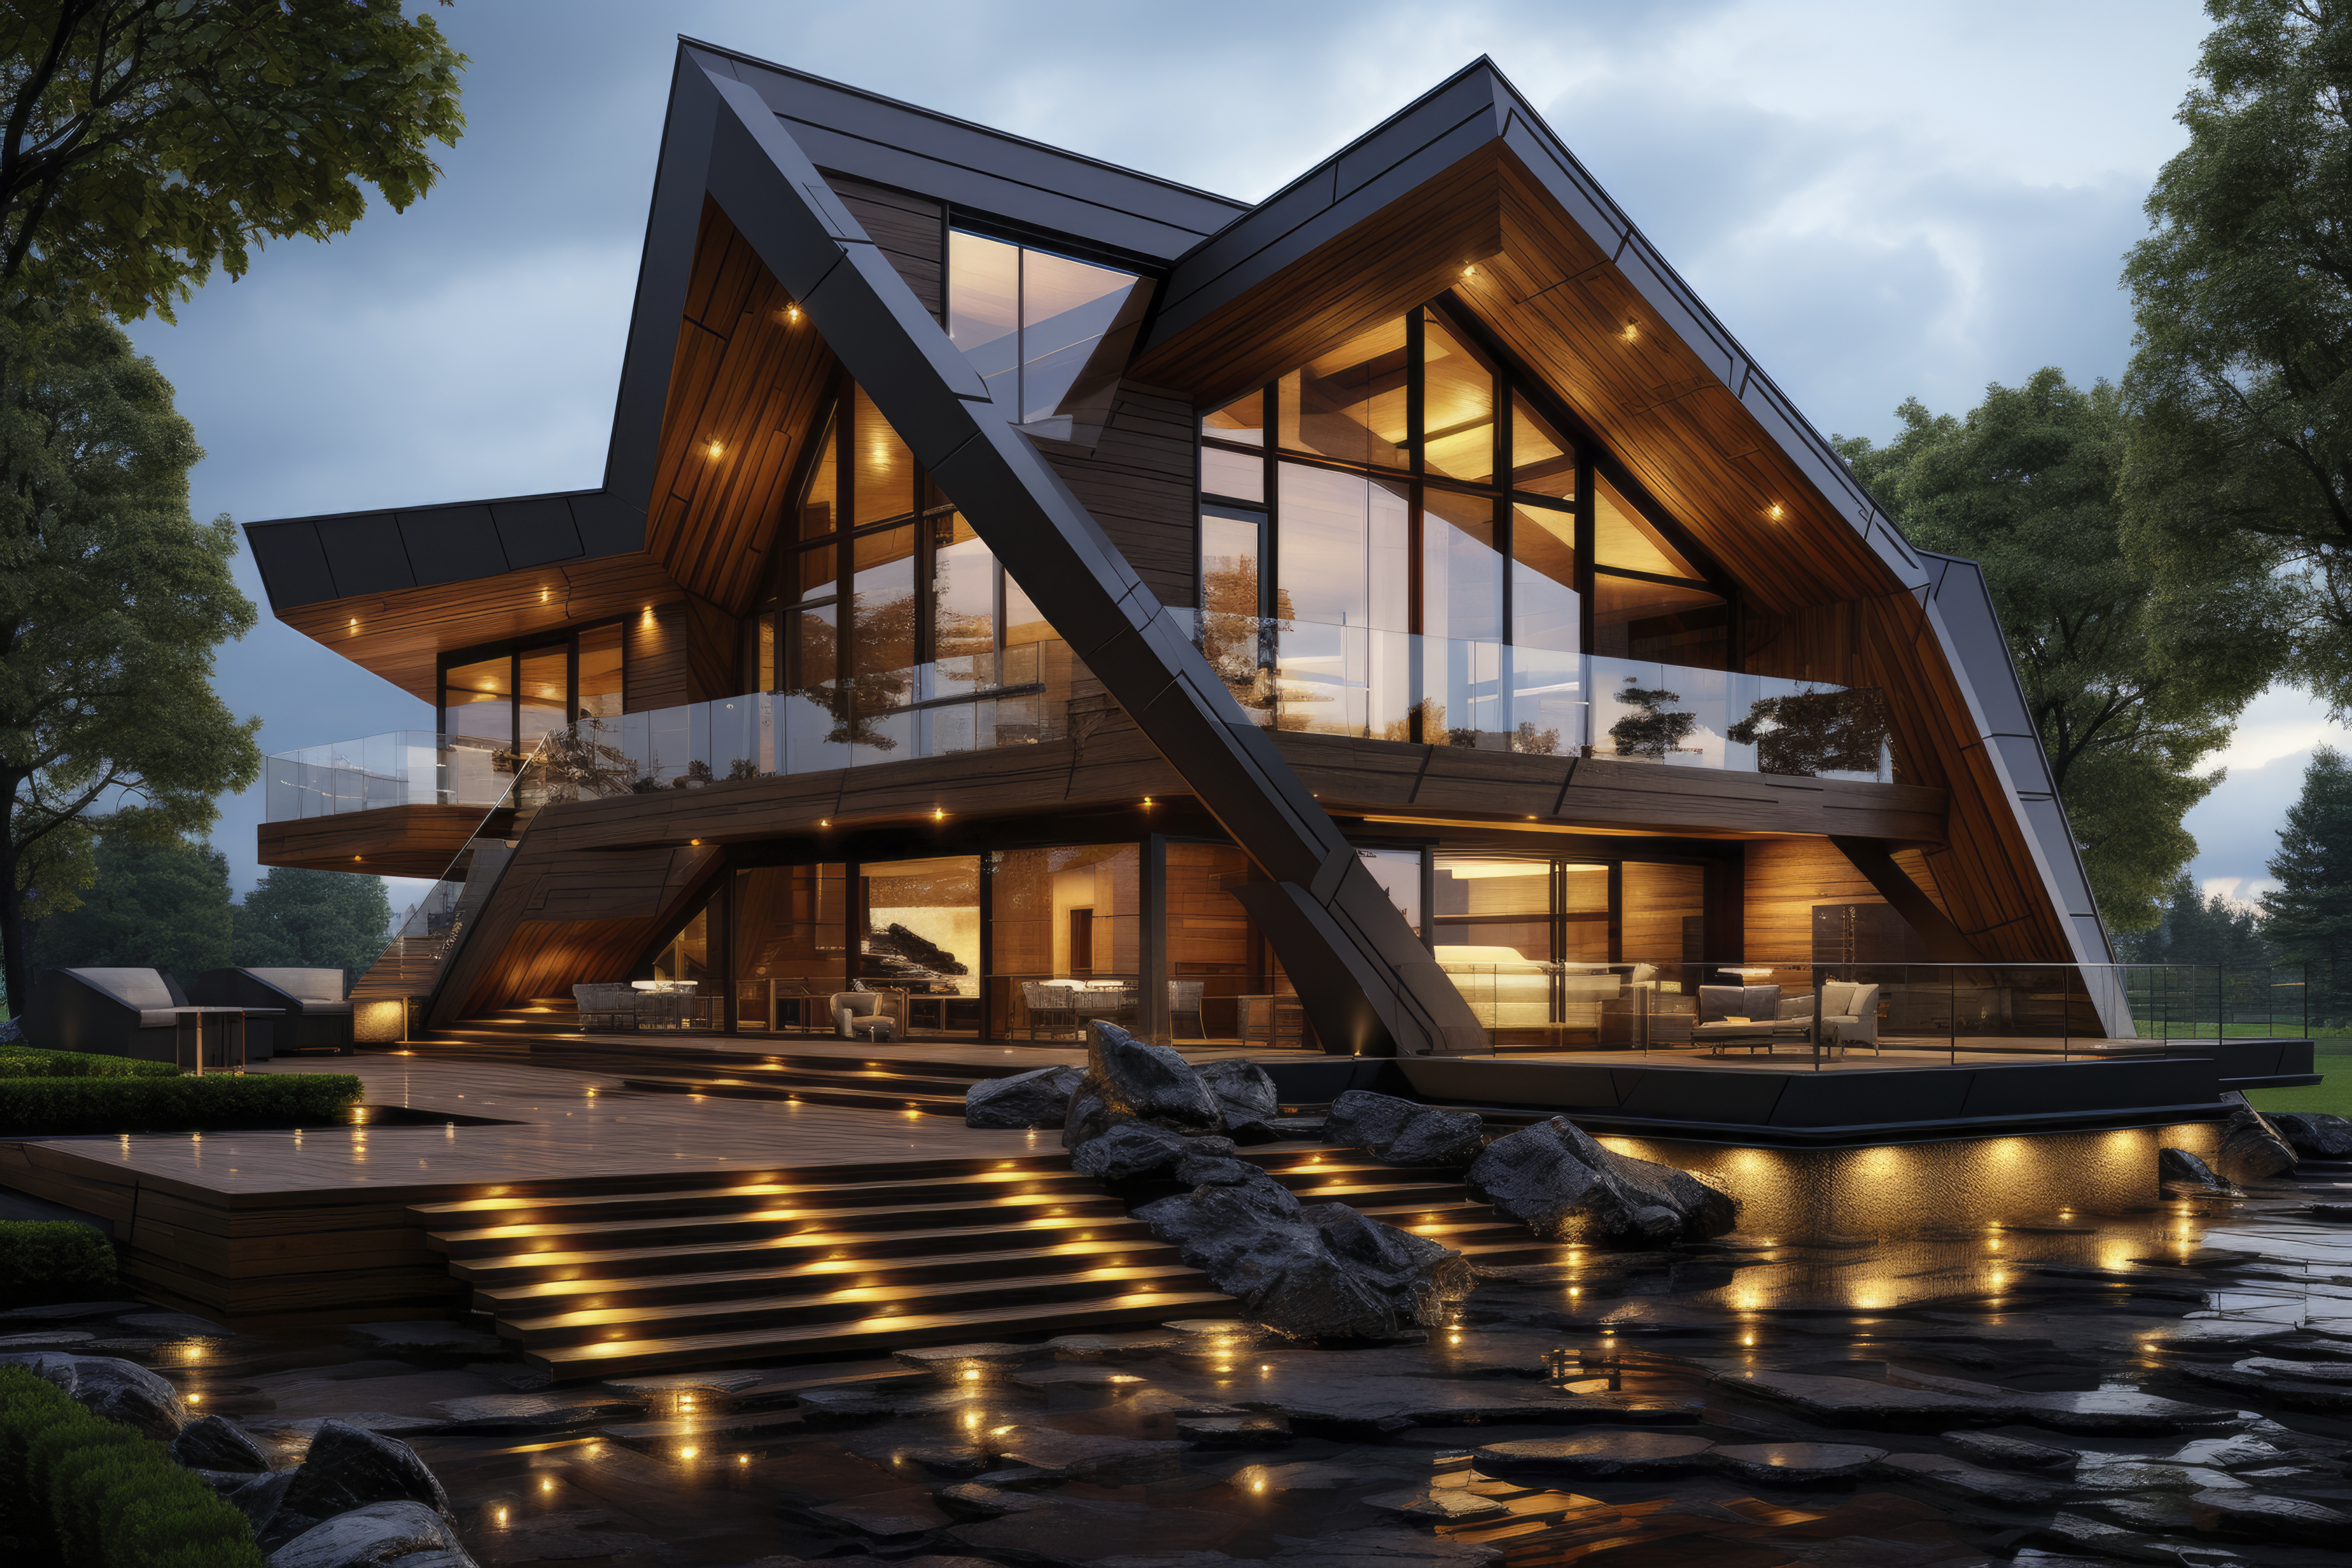

In [1]:
from IPython.display import Image, display

image_path = "ai-generated-house-design.jpg"
display(Image(filename=image_path))

# Project Description
This project focuses on predicting house prices using a publicly available dataset. The dataset includes key attributes such as location, property size, number of rooms, and other features that influence property values. The primary objective is to develop machine-learning models capable of accurately forecasting house prices. This involves identifying the most significant factors affecting property values and providing actionable insights to assist real estate agents, buyers, and sellers in making informed decisions, ultimately optimizing market strategies and enhancing customer satisfaction.



# Key Objectives
1. Data Exploration and Preprocessing
Perform exploratory data analysis (EDA) to understand the dataset’s structure and uncover trends in property prices. Clean the data by addressing missing values, handling outliers, and encoding categorical variables such as property types or locations.

2. Feature Engineering
Develop and refine features to enhance model performance by identifying relationships between property attributes (e.g., size, location, and amenities) and house prices. Incorporate derived features like price per square foot or neighborhood quality scores.

3. Model Development
Utilize machine learning algorithms, including Multiple Linear Regression, Random Forest Regressor, and XGBoost Regressor, to predict house prices. Compare the performance of these models to identify the most accurate and efficient approach.

4. Model Evaluation
Evaluate each model’s performance using metrics such as R², Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). Ensure the models generalize well to unseen data and are robust against variability in property attributes.

5. Insights and Recommendations
Analyze model outputs to identify the most influential factors affecting house prices. Provide actionable insights for real estate professionals, buyers, and sellers to guide property investments and pricing strategies.

# Tools and Technologies
Programming: Python (Pandas, NumPy, Scikit-learn, XGBoost)
Environment: Jupyter Notebooks
Visualization: Matplotlib, Seaborn
Machine Learning: Multiple Linear Regression, Random Forest Regressor, XGBoost Regressor

# Part 1: Data Pre-processing

In [2]:
#Importing all the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('train.csv')
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
752,753,20,RL,79.0,9236,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,217000
916,917,20,C (all),50.0,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,Abnorml,35311
1351,1352,60,RL,70.0,9247,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,171000
717,718,20,RL,80.0,10000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2008,WD,Normal,157000
601,602,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000


In [4]:
df.shape

(1460, 81)

In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
#Finding the statistical summary of the df.
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
print(df.dtypes)

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


In [9]:
#Finding the categorical variables.
len(df.select_dtypes(include='object').columns)

43

In [10]:
len(df.select_dtypes(include=['float64','int64']).columns)

38

II) Dealing with missing values.

In [11]:
#Finding the columns with missing values.
if df.isnull().sum().any():
    print(df.columns[df.isnull().any()])

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')


In [12]:
#Finding missing values as a percentage of total values.
null_percent = df.isnull().sum() / df.shape[0] * 100

In [13]:
null_percent

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [14]:
#Dropping columns with a null percentage greater than 50.
cols_to_drop = null_percent[null_percent > 50].keys()

In [15]:
cols_to_drop

Index(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [16]:
df = df.drop(columns= ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'])

In [17]:
df.shape

(1460, 76)

In [18]:
if df.isnull().sum().any():
    print(df.columns[df.isnull().any()])

Index(['LotFrontage', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual',
       'GarageCond'],
      dtype='object')


In [19]:
#Replacing the missing values with the mean for numerical columns.
df[['LotFrontage','MasVnrArea', 'GarageYrBlt']] = df[['LotFrontage','MasVnrArea', 'GarageYrBlt']].fillna(df[['LotFrontage','MasVnrArea', 'GarageYrBlt']].mean())

In [20]:
if df.isnull().sum().any():
    print(df.columns[df.isnull().any()])

Index(['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond'],
      dtype='object')


In [21]:
#Adding column mode to categorical columns.
df.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [22]:
len(df.columns[df.isnull().any()])

11

In [23]:
columns_to_fill = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
                   'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for column in columns_to_fill:
    df[column] = df[column].fillna(df[column].mode()[0])

In [24]:
len(df.columns[df.isnull().any()])

0

III) Creating bins to see the distribution of the prices.

Text(0, 0.5, 'Count')

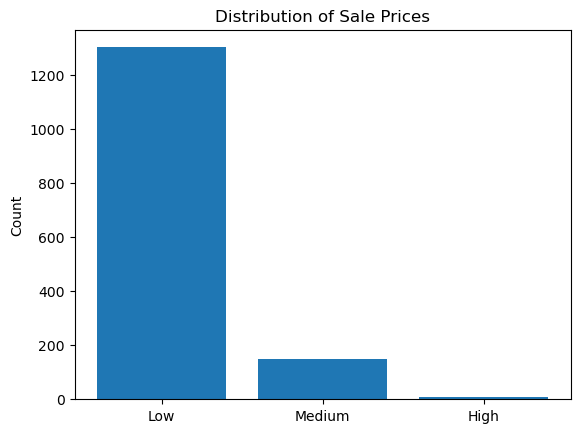

In [25]:
bins = np.linspace(min(df['SalePrice']), max(df['SalePrice']),4)
group_names = ["Low","Medium","High"]
df["Price_binned"] = pd.cut(df["SalePrice"], bins, labels = group_names, include_lowest= True)
plt.bar(group_names,df["Price_binned"].value_counts())
plt.title("Distribution of Sale Prices")
plt.ylabel("Count")

IV) Distplot of the target variable.

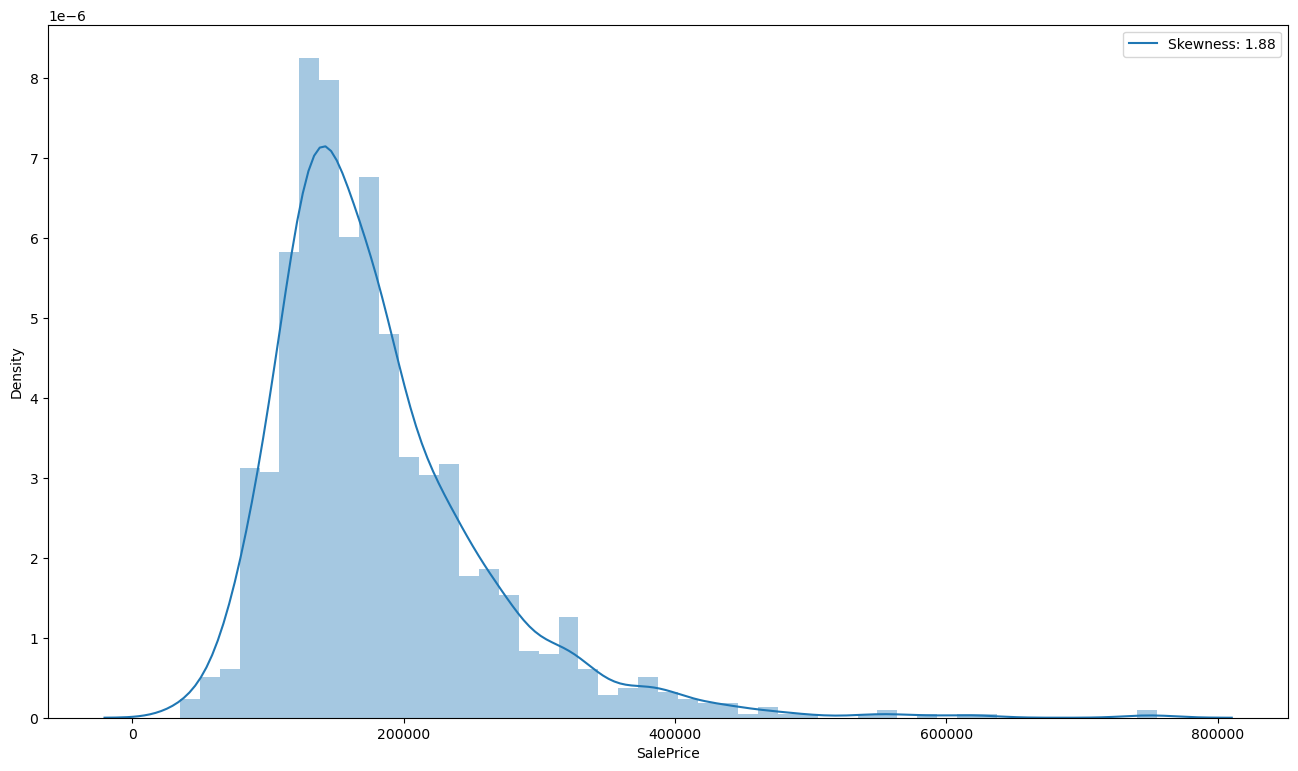

In [26]:
plt.figure(figsize=(16,9))
bar = sns.distplot(df['SalePrice'])
bar.legend(["Skewness: {:.2f}".format(df['SalePrice'].skew())])
plt.show()

V) Correlation Matrix.

In [27]:
df_2 = df.drop(columns='SalePrice')

In [28]:
df_2.shape

(1460, 76)

<Axes: title={'center': 'Correlation with SalePrice'}>

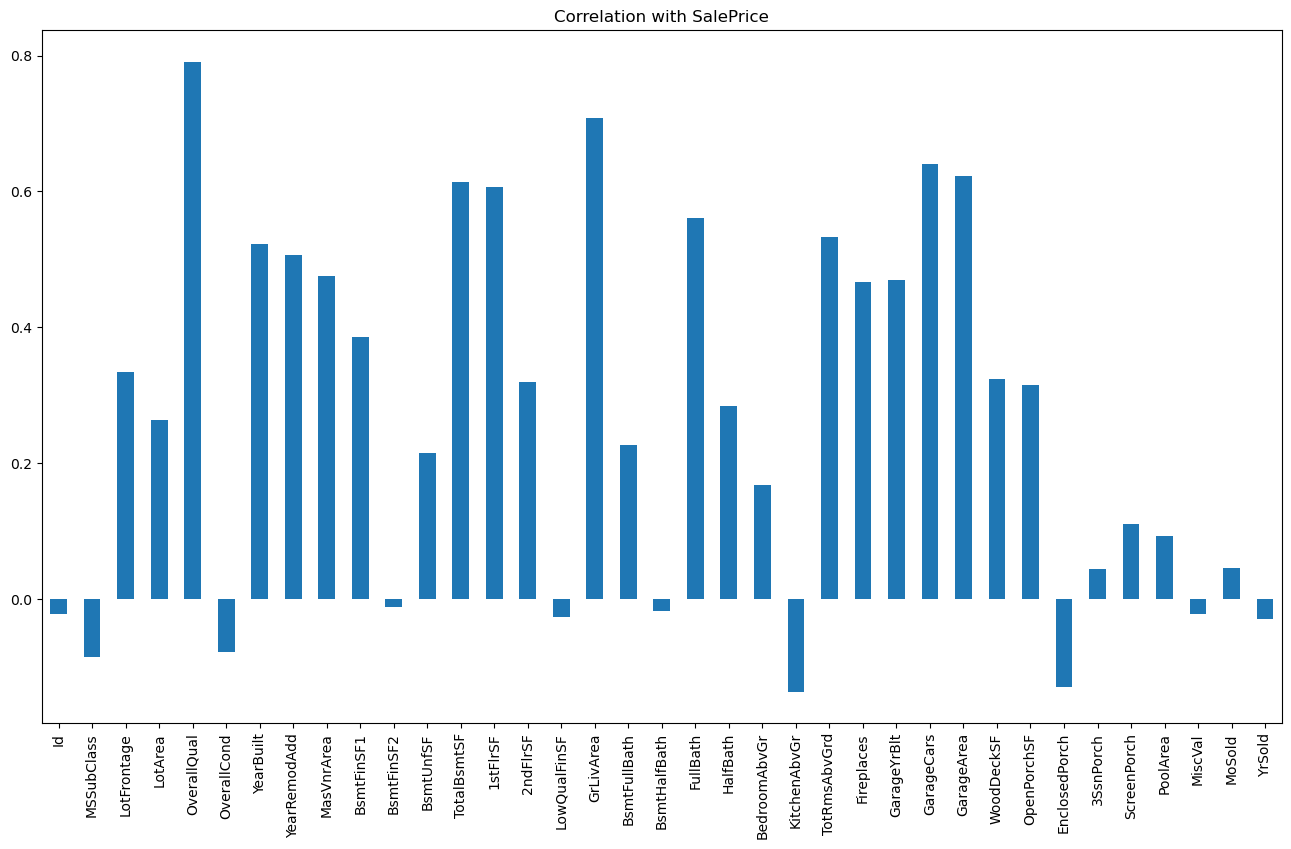

In [29]:
# Selecting only numeric columns from df_2
numeric_df_2 = df_2.select_dtypes(include=['number'])

numeric_df_2.corrwith(df['SalePrice']).plot.bar(figsize=(16,9), title='Correlation with SalePrice')

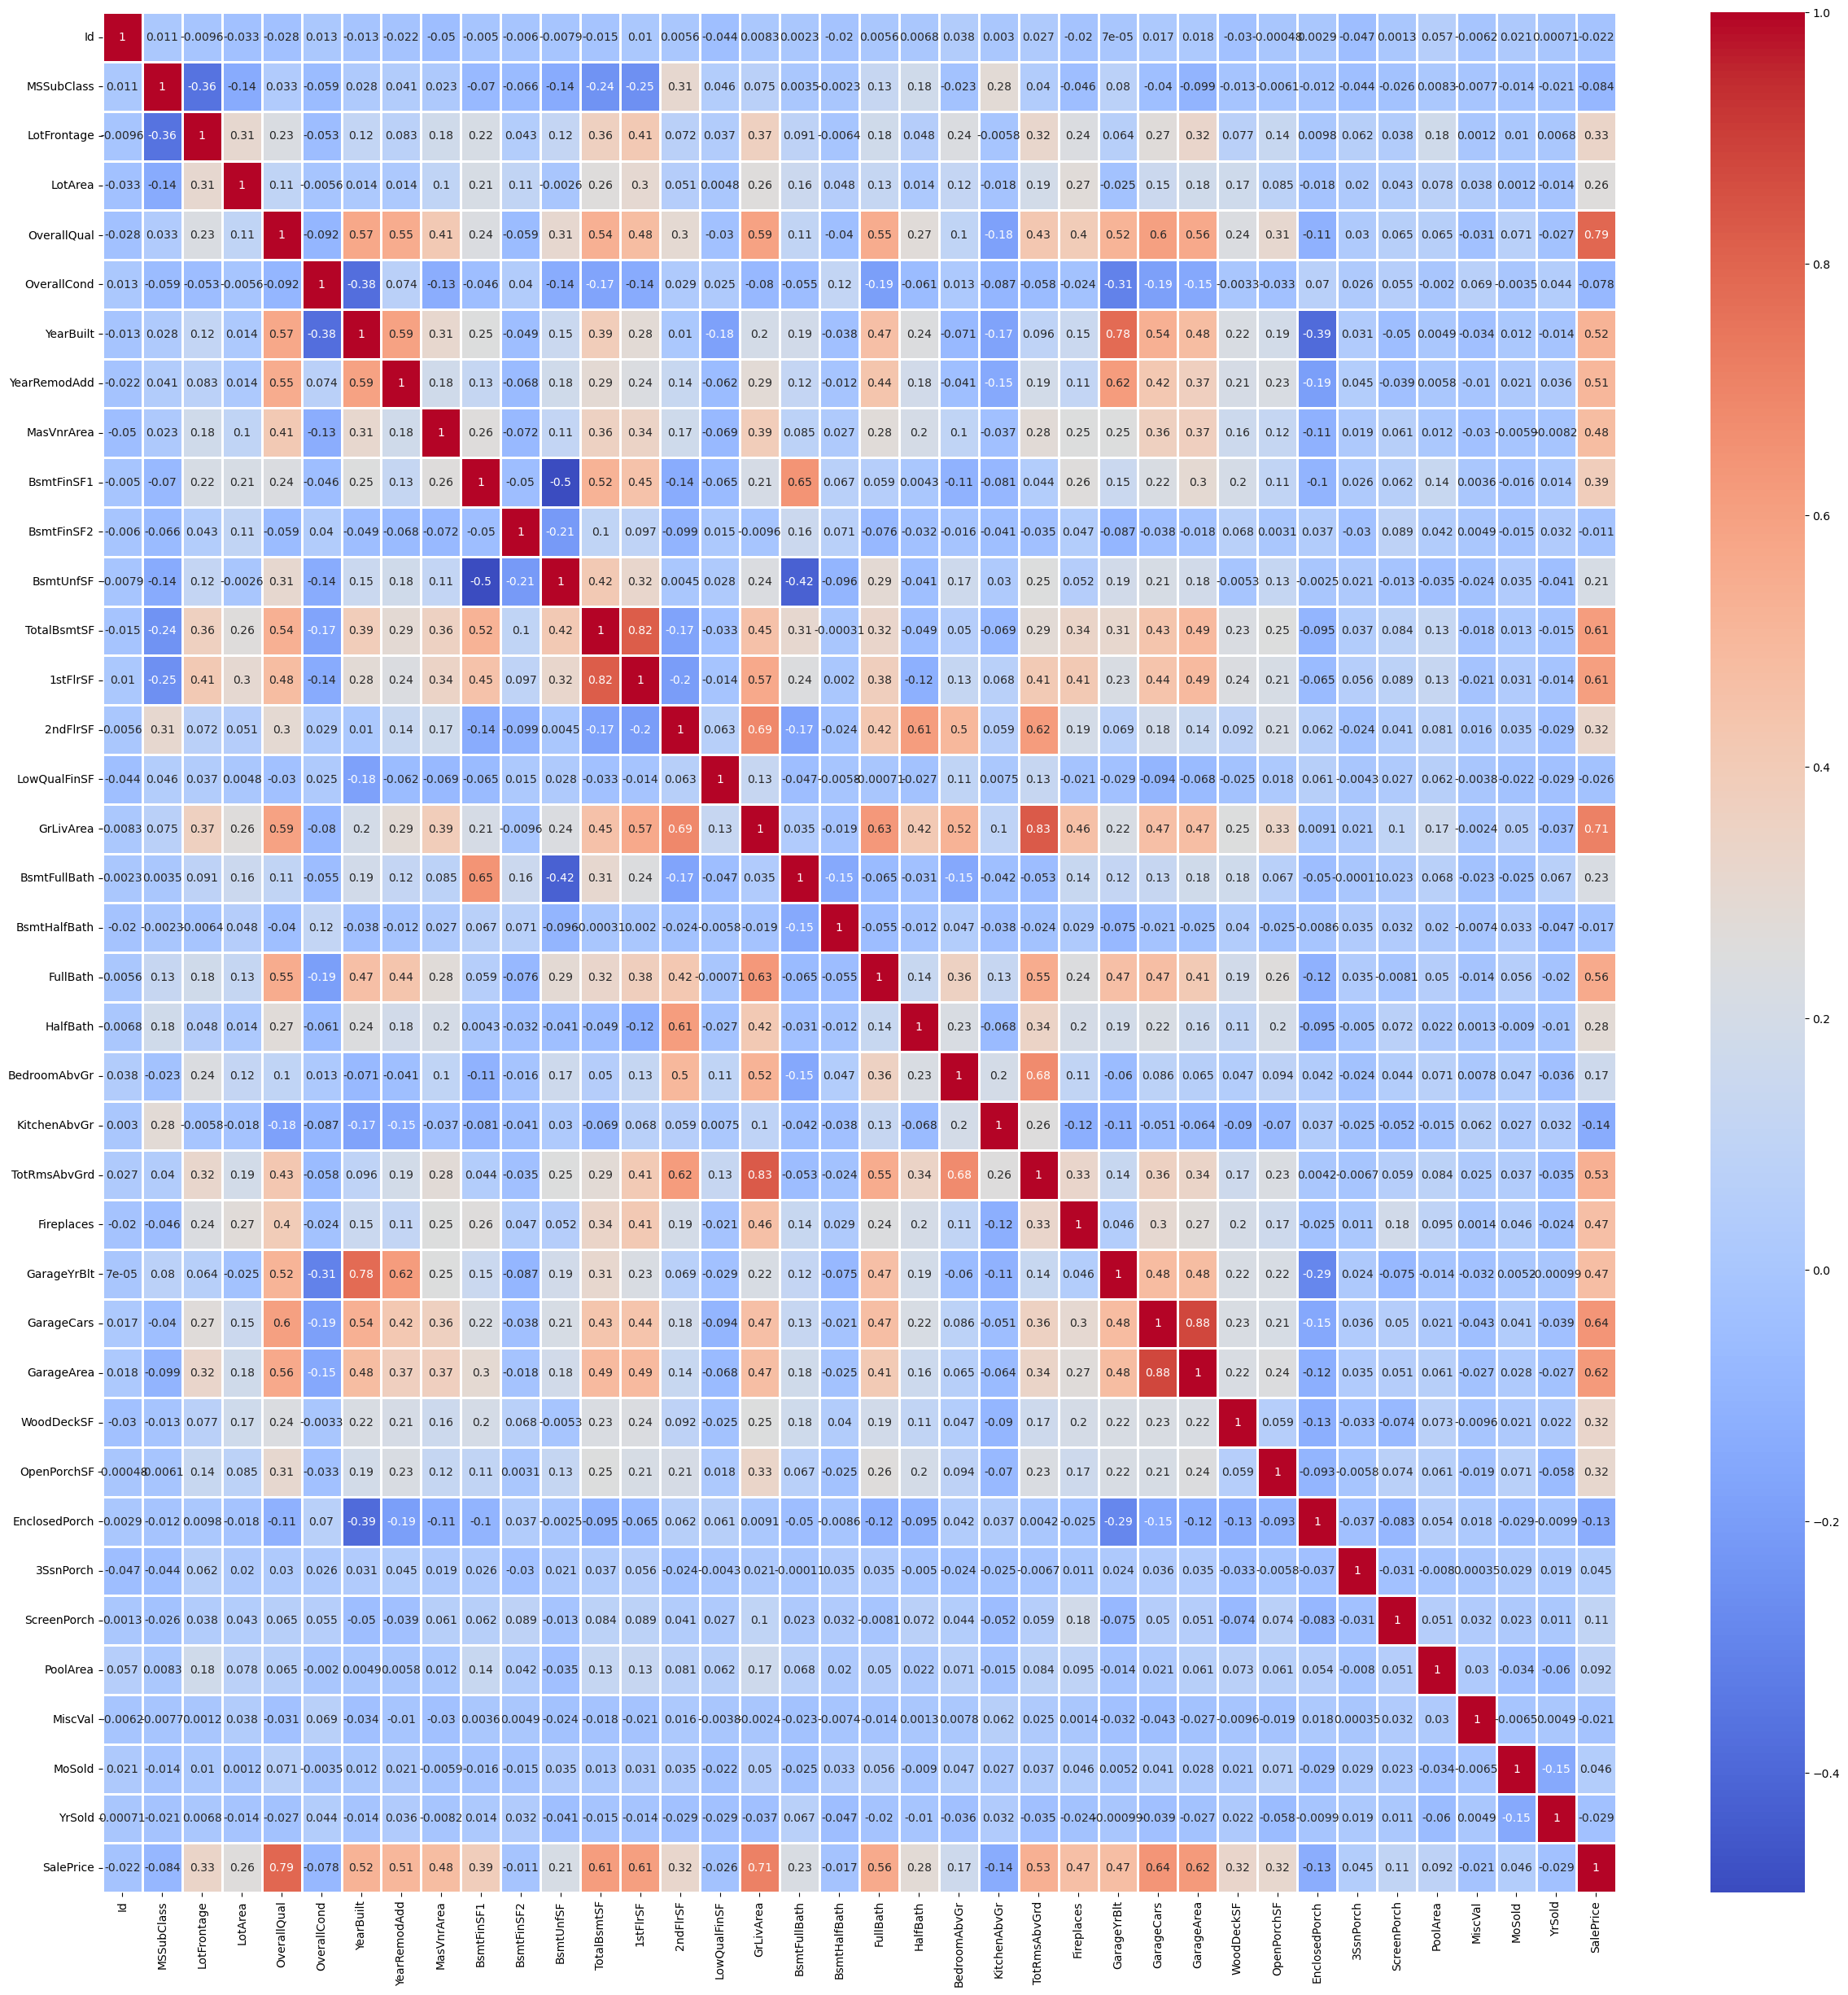

In [30]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(30, 30))
fig = sns.heatmap(data=numeric_df.corr(), cmap='coolwarm', annot= True, linewidths=1)

In [31]:
corr = numeric_df.corr()

In [32]:
corr_features = corr.index[abs(corr['SalePrice']) > 0.5]

In [33]:
corr_features

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea',
       'SalePrice'],
      dtype='object')

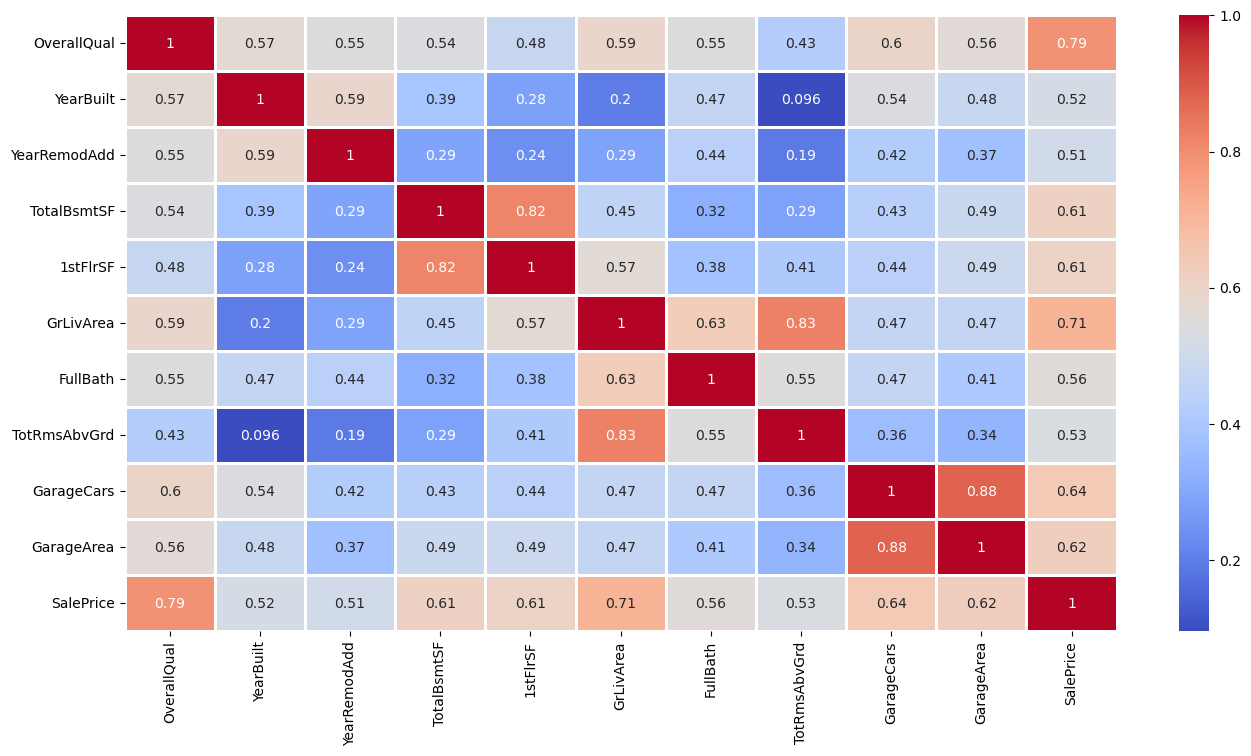

In [34]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(16, 8))
fig = sns.heatmap(data=df[corr_features].corr(), cmap='coolwarm', annot= True, linewidths=1)

VI) Dealing with categorical values.

In [35]:
df.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [36]:
df = pd.get_dummies(data=df, drop_first= True)

In [37]:
df.shape

(1460, 237)

VI) Splitting the dataset.

In [38]:
#Independent variable.
X = df.drop(columns= 'SalePrice')

In [39]:
X.shape

(1460, 236)

In [40]:
y = df['SalePrice']

In [41]:
#Dependent variable.
y.shape

(1460,)

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [44]:
X_train.shape

(1168, 236)

In [45]:
X_test.shape

(292, 236)

In [46]:
y_train.shape

(1168,)

In [47]:
y_test.shape

(292,)

VI) Feature Scaling.

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

In [50]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
X_train

array([[-1.33511349, -0.86400154,  0.63978128, ..., -0.30431877,
        -0.33995336, -0.07764847],
       [ 0.09227838, -0.86400154,  0.73255553, ...,  3.28602797,
        -0.33995336, -0.07764847],
       [ 0.24428018,  0.32716206, -0.00732105, ..., -0.30431877,
        -0.33995336, -0.07764847],
       ...,
       [-0.32810159,  2.47125654, -2.14344624, ..., -0.30431877,
        -0.33995336, -0.07764847],
       [ 1.4816698 , -0.86400154,  2.49526628, ..., -0.30431877,
        -0.33995336, -0.07764847],
       [ 0.29890582, -0.86400154, -0.00963848, ..., -0.30431877,
        -0.33995336, -0.07764847]])

In [52]:
X_test

array([[ 0.75253618,  0.08892934,  0.91810403, ..., -0.30431877,
        -0.33995336, -0.07764847],
       [-0.89335827, -0.14930338, -0.00732105, ..., -0.30431877,
        -0.33995336, -0.07764847],
       [ 1.29404258, -0.86400154, -0.4271226 , ..., -0.30431877,
        -0.33995336, -0.07764847],
       ...,
       [-0.12859923, -0.86400154,  0.91810403, ..., -0.30431877,
         2.94157994, -0.07764847],
       [-1.30186309,  1.51832566, -1.35486511, ..., -0.30431877,
         2.94157994, -0.07764847],
       [ 0.66703517,  0.56539478, -0.00732105, ..., -0.30431877,
        -0.33995336, -0.07764847]])

# Part 2: Building the models.

I) Multiple Linear Regression.

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [55]:
y_pred = model_lr.predict(X_test)

In [56]:
from sklearn.metrics import r2_score

In [57]:
score = r2_score(y_test, y_pred)

In [58]:
score

-2.0102784012689238e+22

II) Random Forest Regressor.

In [59]:
from sklearn.ensemble import RandomForestRegressor
regressor_rf = RandomForestRegressor(random_state=0)
regressor_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [60]:
y_pred = regressor_rf.predict(X_test)

In [61]:
score = r2_score(y_test, y_pred)

In [62]:
score

0.9077080077975046

III) XB Boost Regressor

In [63]:
from xgboost import XGBRegressor

In [64]:
regressor_xgb = XGBRegressor()
regressor_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [65]:
y_pred = regressor_xgb.predict(X_test)

In [66]:
score = r2_score(y_test, y_pred)

In [67]:
score

0.8996119485343336

# Part 3: Hyper Parameter Tuning.

In [68]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
parameters = {
    'n_estimators':[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000],
    'max_depth':[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf':[1, 2, 4],
    'max_features':['auto', 'sqrt'],
    'bootstrap':[True, False]    
}

In [70]:
random_cv = RandomizedSearchCV(estimator=regressor_rf, param_distributions=parameters, n_iter=50, cv=5,
                               verbose=2, n_jobs=-1, random_state=0)

In [72]:
random_cv.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=0, verbose=2)

In [73]:
random_cv.best_estimator_

RandomForestRegressor(bootstrap=False, max_depth=50, max_features='sqrt',
                      n_estimators=1200, random_state=0)

In [74]:
random_cv.best_params_

{'n_estimators': 1200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 50,
 'bootstrap': False}

In [78]:
regressor = RandomForestRegressor(
    bootstrap=False,
    ccp_alpha=0.0,
    criterion='squared_error',
    max_depth=50,
    max_features='sqrt',
    max_leaf_nodes=None,
    max_samples=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=1,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    n_estimators=1200,
    n_jobs=None,
    oob_score=False,
    random_state=None,
    verbose=0,
    warm_start=False
)
regressor.fit(X_train, y_train)

RandomForestRegressor(bootstrap=False, max_depth=50, max_features='sqrt',
                      n_estimators=1200)

In [80]:
y_pred = regressor.predict(X_test)

In [81]:
r2_score(y_test, y_pred)

0.8632724257769027